In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

=== Statistiques descriptives ===
       Retard moyen de tous les trains à l'arrivée  Nombre de circulations prévues  Nombre de trains annulés  Durée moyenne du trajet
count                                     12054.00                        11788.00                  11788.00                 11680.00
mean                                          6.06                          271.11                      8.66                   170.94
std                                           6.93                          182.46                     22.57                    88.11
min                                        -472.64                            0.00                      0.00                     0.00
25%                                           3.44                          151.00                      0.00                   100.00
50%                                           5.45                          229.00                      2.00                   163.00
75%                         

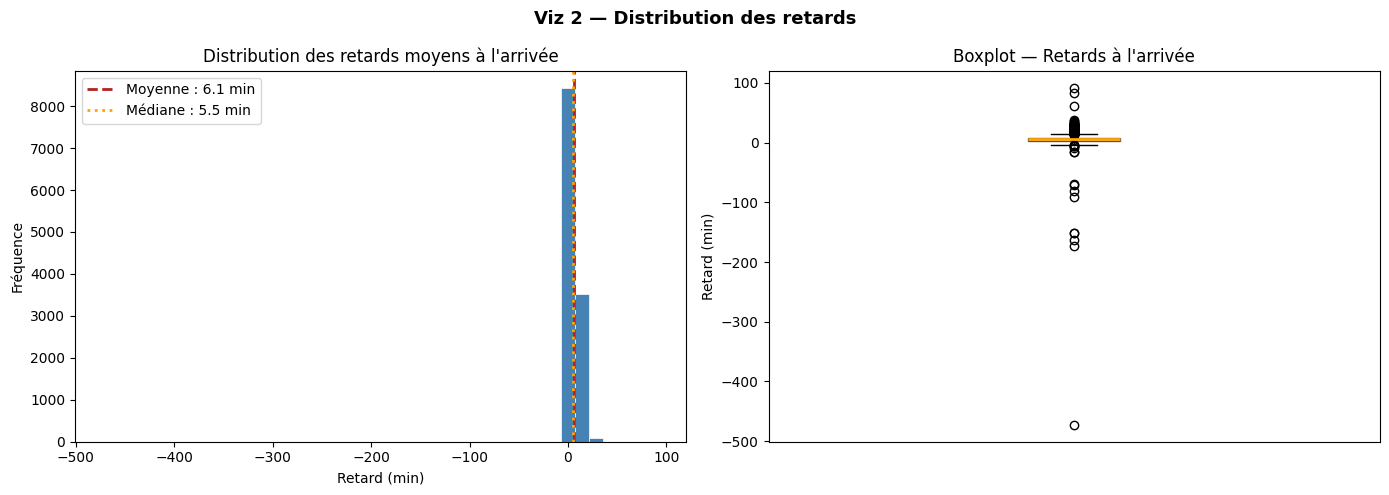

Interprétation : Distribution asymétrique à droite — majorité des trains < 5 min de retard, mais quelques perturbations importantes tirent la moyenne vers le haut.


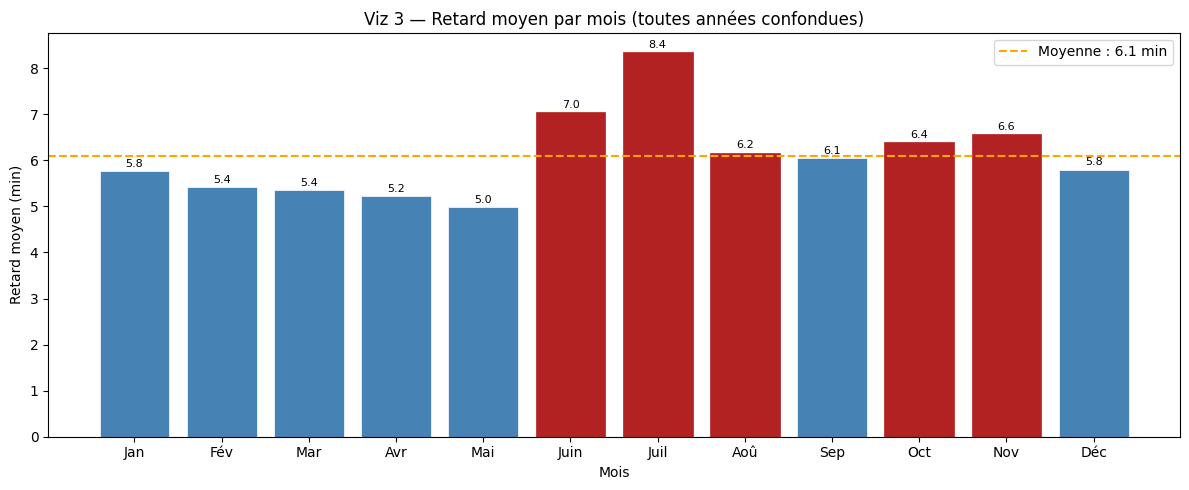

Interprétation : Les mois d'hiver et de forte activité dépassent la moyenne (rouge). Le mois est donc une variable prédictive pertinente pour le modèle.


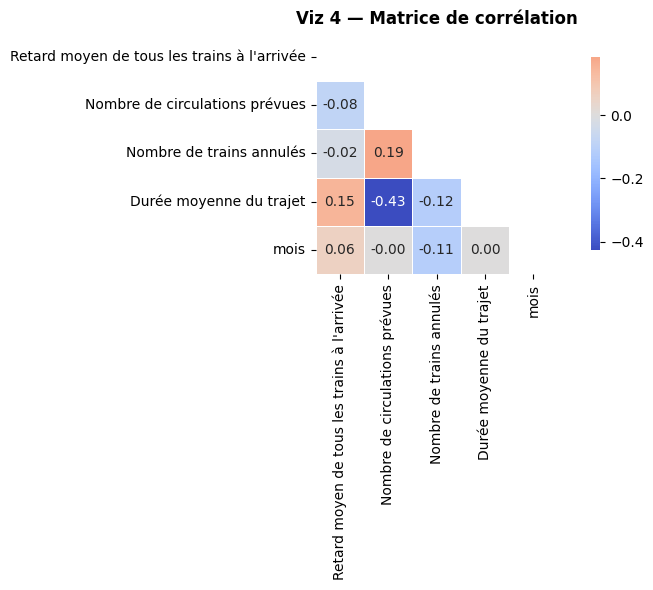

Interprétation : Le nombre de trains annulés est positivement corrélé au retard moyen. La durée du trajet montre également une corrélation modérée, confirmant son intérêt comme feature prédictive.


In [15]:
# --- Statistiques descriptives ---
df_clean = pd.read_csv('dataset.csv')

TARGET = "Retard moyen de tous les trains à l'arrivée"

df_clean[TARGET] = pd.to_numeric(df_clean[TARGET], errors='coerce')
df_clean['Nombre de circulations prévues'] = pd.to_numeric(df_clean['Nombre de circulations prévues'], errors='coerce')
df_clean['Nombre de trains annulés'] = pd.to_numeric(df_clean['Nombre de trains annulés'], errors='coerce')
df_clean['Durée moyenne du trajet'] = pd.to_numeric(df_clean['Durée moyenne du trajet'], errors='coerce')
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean['mois'] = df_clean['Date'].dt.month

print("=== Statistiques descriptives ===")
desc = df_clean[[TARGET, 'Nombre de circulations prévues', 'Nombre de trains annulés', 'Durée moyenne du trajet']].describe().round(2)
print(desc.to_string())
trajets = df_clean[['Gare de départ', "Gare d'arrivée"]].drop_duplicates().shape[0]
print(f"\nNombre de trajets uniques : {trajets}")
print(f"Retard moyen global       : {df_clean[TARGET].mean():.2f} min")
print(f"Retard médian global      : {df_clean[TARGET].median():.2f} min")
print(f"Retard max enregistré     : {df_clean[TARGET].max():.2f} min")

# --- Viz 2 : Distribution des retards ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data = df_clean[TARGET].dropna()

axes[0].hist(data, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(data.mean(),   color='firebrick', linewidth=2, linestyle='--', label=f'Moyenne : {data.mean():.1f} min')
axes[0].axvline(data.median(), color='orange',    linewidth=2, linestyle=':',  label=f'Médiane : {data.median():.1f} min')
axes[0].set_title("Distribution des retards moyens à l'arrivée")
axes[0].set_xlabel('Retard (min)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

axes[1].boxplot(data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='orange', linewidth=2))
axes[1].set_title("Boxplot — Retards à l'arrivée")
axes[1].set_ylabel('Retard (min)')
axes[1].set_xticks([])

plt.suptitle('Viz 2 — Distribution des retards', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Interprétation : Distribution asymétrique à droite — majorité des trains < 5 min de retard, mais quelques perturbations importantes tirent la moyenne vers le haut.")

# --- Viz 3 : Saisonnalité mensuelle ---
MOIS_LABELS = {1:'Jan',2:'Fév',3:'Mar',4:'Avr',5:'Mai',6:'Juin',
               7:'Juil',8:'Aoû',9:'Sep',10:'Oct',11:'Nov',12:'Déc'}

monthly_avg = df_clean.groupby('mois')[TARGET].mean()
mean_val = monthly_avg.mean()

plt.figure(figsize=(12, 5))
bars = plt.bar([MOIS_LABELS[m] for m in monthly_avg.index], monthly_avg.values,
               color='steelblue', edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, monthly_avg.values):
    if val > mean_val:
        bar.set_color('firebrick')
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.axhline(mean_val, color='orange', linewidth=1.5, linestyle='--',
            label=f'Moyenne : {mean_val:.1f} min')
plt.title('Viz 3 — Retard moyen par mois (toutes années confondues)')
plt.xlabel('Mois')
plt.ylabel('Retard moyen (min)')
plt.legend()
plt.tight_layout()
plt.show()
print("Interprétation : Les mois d'hiver et de forte activité dépassent la moyenne (rouge). Le mois est donc une variable prédictive pertinente pour le modèle.")
# --- Viz 4 : Corrélation heatmap ---
num_cols = [TARGET, 'Nombre de circulations prévues', 'Nombre de trains annulés', 'Durée moyenne du trajet', 'mois']
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Viz 4 — Matrice de corrélation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Interprétation : Le nombre de trains annulés est positivement corrélé au retard moyen. La durée du trajet montre également une corrélation modérée, confirmant son intérêt comme feature prédictive.")